<a href="https://colab.research.google.com/github/albaugh/CHE7507/blob/main/NN_for_H2_Loading_in_MOFs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Alex Albaugh.  Wayne State.  AICHE Mid-Career Workshop 2026.

# Introduction

Artificial neural networks are a predictive model.  They consist of an input layer and an output layer.  In between are hidden layers.  Each hidden layer consists of a number of artificial neurons that "activate" based on their input.  Each connection between neurons has a weight and each neuron also has a bias.  After setting the structure of our neural network, we must train these weights and biases to give our desired output.

Several <code>Python</code> packages are available for efficiently implementing neural networks.  The two most common packages are <code>TensorFlow</code> and <code>PyTorch</code>.  We are going to use a library called <code>Keras</code>, which is built on top of <code>TensorFlow</code>.  <code>Keras</code> will allow us to abstract away some of the more complicated synthax of <code>TensorFlow</code>.  This will allow us to easily construct and train networks, but may come at the cost of advanced features and controls for more complex tasks.

Let's get some data to build a network with.  We'll use Yamil Colón's metal-organic framework data set.  Metal-organic frameworks (MOFs) are crystal structures made from metallic cluster bound with organic linkers into porous 3D structures.  With a large range of metallic and organic components available, there are many possible MOF structures.  MOFs have applications in gas separation and storage.  Here we'll look at about 13,000 different MOFs and we'll build a model to predict their hydrogen storage capacity based on their gravimentric surface area (surface area per mass), volumentric surface area (surface area per volume), void fraction, limiting pore diameter, and largest pore diameter.

The data comes from "Transfer Learning Study of Gas Adsorption in Metal-Organic Frameworks." <url>https://pubs.acs.org/doi/full/10.1021/acsami.0c06858</url>

Let's poke around our data set first.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import sklearn
from tqdm.keras import TqdmCallback

!wget -q https://raw.githubusercontent.com/albaugh/CHE7507/main/nn_viz.py
from nn_viz import draw_network

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/albaugh/CHE7507/refs/heads/main/Lecture12/mof_data.csv')

df.head()

,MOF ID,void fraction,Vol. S.A.,Grav. S.A.,Pore diameter Limiting,Pore diameter Largest,H2@100 bar/77K (g/L),H2@100 bar/77K (mol/kg),H2@100 bar/77K (wt%),H2@100 bar/130K (g/L),...,5 bar Selectivity,topology,First nodular symmetry code,First nodular character,First nodular ID,Second nodular symmetry code,Second nodular character,Second nodular ID,Connecting building block ID,Nonsense
0,1,0.69,1763,2215.0,6.2,7.9,47.5,29.8,5.6,30.4,...,6.8,acs,7,metaliic,4,7,metallic,4,10.0,NaN
1,2,0.64,1490,1791.0,8.1,8.8,44.6,26.8,5.1,27.4,...,7.3,acs,7,metaliic,4,7,metallic,4,11.0,NaN
2,3,0.75,2073,2956.0,8.4,9.6,51.6,36.8,6.9,30.3,...,4.9,acs,7,metaliic,4,7,metallic,4,12.0,NaN
3,4,0.76,2096,2850.0,9.5,10.7,49.8,33.8,6.3,27.6,...,3.5,acs,7,metaliic,4,7,metallic,4,13.0,NaN
4,5,0.79,2109,3638.0,9.5,10.9,51.3,44.1,8.1,28.5,...,3.4,acs,7,metaliic,4,7,metallic,4,14.0,NaN


Our features will be the void fraction, volumetric surface area, gravimetric surface area, limiting pore diameter, and largest pore diameter.  Our target will be the hydrogen loading in g/L at 243 K.

In [3]:
features = ['void fraction','Vol. S.A.','Grav. S.A.','Pore diameter Limiting','Pore diameter Largest']
output = 'H2@100 bar/243K (g/L)'

X = df[features].values
y = df[output].values

Let's visualize our distributions.

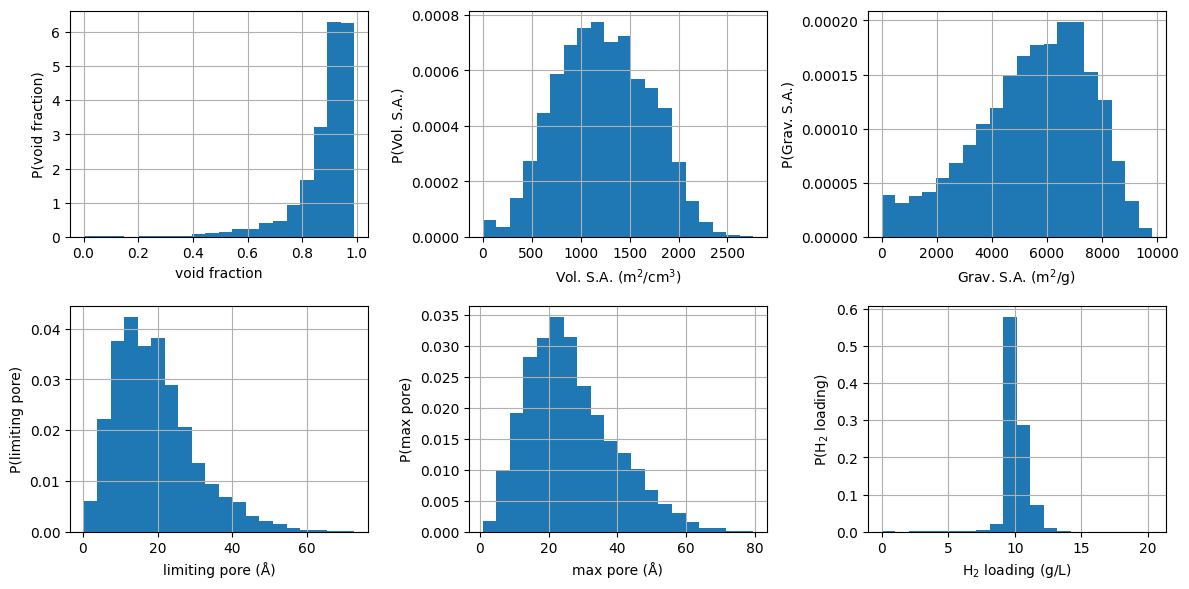

In [4]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 6))

axes[0, 0].hist(X[:, 0], bins=20, density=True)
axes[0, 1].hist(X[:, 1], bins=20, density=True)
axes[0, 2].hist(X[:, 2], bins=20, density=True)
axes[1, 0].hist(X[:, 3], bins=20, density=True)
axes[1, 1].hist(X[:, 4], bins=20, density=True)
axes[1, 2].hist(y, bins=20, density=True)

axes[0, 0].set_xlabel('void fraction')
axes[0, 0].set_ylabel('P(void fraction)')
axes[0, 1].set_xlabel('Vol. S.A. (m$^2$/cm$^{3}$)')
axes[0, 1].set_ylabel('P(Vol. S.A.)')
axes[0, 2].set_xlabel('Grav. S.A. (m$^2$/g)')
axes[0, 2].set_ylabel('P(Grav. S.A.)')
axes[1, 0].set_xlabel('limiting pore (Å)')
axes[1, 0].set_ylabel('P(limiting pore)')
axes[1, 1].set_xlabel('max pore (Å)')
axes[1, 1].set_ylabel('P(max pore)')
axes[1, 2].set_xlabel('H$_2$ loading (g/L)')
axes[1, 2].set_ylabel('P(H$_2$ loading)')
for ax in axes.flat:
    ax.grid()

plt.tight_layout()
plt.show()

Neural networks perform best with standardized data.  This keeps all of the weights, biases, and gradients of an approximately equivalent size and aids with training.  It's good practice to standardize your features.

In [5]:
scaler = sklearn.preprocessing.StandardScaler()
X = scaler.fit_transform(X)

It's never a bad idea to fit a linear model to get a baseline for comparison.

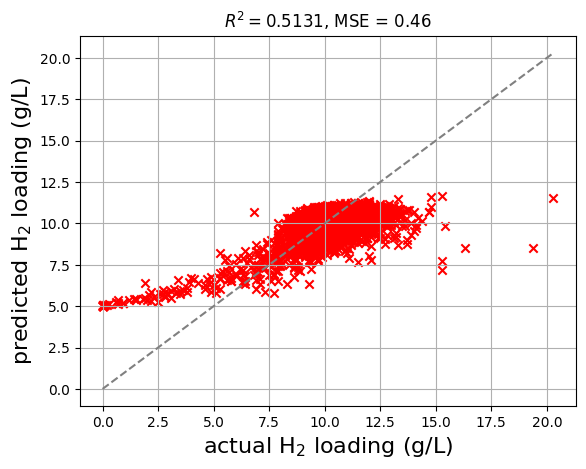

In [6]:
linear_model = sklearn.linear_model.LinearRegression()
linear_model.fit(X, y)

y_pred = linear_model.predict(X)

R2 = sklearn.metrics.r2_score(y, y_pred)

mse = sklearn.metrics.mean_squared_error(y, y_pred)

fig, ax = plt.subplots()
ax.scatter(y, y_pred, color='r', marker='x')
ax.plot([np.min(y), np.max(y)], [np.min(y), np.max(y)], color='gray', linestyle='--')
ax.grid()
ax.set_xlabel('actual H$_2$ loading (g/L)', fontsize=16)
ax.set_ylabel('predicted H$_2$ loading (g/L)', fontsize=16)
ax.set_title('$R^{2}=$'+str(np.round(R2,decimals=4))+', MSE = '+str(np.round(mse,decimals=2)))
plt.show()

# Building and Training Artificial Neural Networks

Here's the basic structure of how to build a neural network with a single hidden layer with 50 neurons.  The hidden layer is called <code>Dense</code> because each of its neurons connects to each neuron in the previous layer and the subsequent layer, making a dense amount of connections.  We'll use a ReLU activation function in our hidden dense layer.  

In [7]:
model = keras.Sequential([ #our model is sequential- it starts at the input, moves through hidden layers, and ends with the output
    keras.Input(shape=(5,)), #with our input layer we define the shape of the input, here we have 5 features
    keras.layers.Dense(10, activation='relu'), #our hidden layer as 64 neurons and a ReLU activationd
    keras.layers.Dense(50, activation='relu'), #our hidden layer as 50 neurons and a ReLU activation ('signoid', 'tanh', 'elu')
    keras.layers.Dense(10, activation='relu'), #our hidden layer as 64 neurons and a ReLU activation
    keras.layers.Dense(1, activation='linear') #our output layer is linear, it takes a linear combinaton of the hidden layer output to return a single value
])

We'll now set up our stochastic gradient descent procedure for training the network.  We can define the learning rate here.

In [8]:
adm = keras.optimizers.Adam()
model.compile(optimizer=adm, loss='mse')

At this point we compile the model, combining our network with the optimizer, and we specify our loss function.  Since we're doing a regression task (we're trying to predict a numerical value), mean squared error (MSE) is a good loss function.  At this point we haven't trained the model, but we are set up to do so.

Another useful tool is the ADAM (adaptive moment estimation) optimizer.  ADAM is based on stochastic gradient descent, but also includes momentum, which is useful for getting out of local minima, and adaptive learning rates, which can make trainng more efficient.

We can see a summary of the model if we want.

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │           550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,131 (4.42 KB)

 Trainable params: 1,131 (4.42 KB)

 Non-trainable params: 0 (0.00 B)

We can now train the network using <code>fit</code>.  Here we'll set the batch size and the number of epochs.  Using this neat <code>callback</code>, we can get a more compact view of our training progess.

In [10]:
model.fit(X, y, epochs=100, batch_size=32, verbose=0, callbacks=[TqdmCallback()])

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Using our saved history, let's see what the training procedure did.  And what our performance looks like.

423/423 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Text(0.5, 1.0, '$R^{2}=$0.8153, MSE = 0.18')

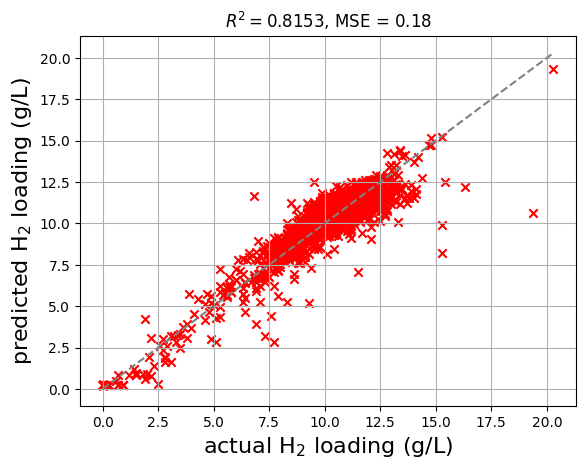

In [11]:
y_pred = model.predict(X)

R2 = sklearn.metrics.r2_score(y, y_pred)

mse = sklearn.metrics.mean_squared_error(y, y_pred)

fig, ax = plt.subplots()
ax.scatter(y, y_pred, color='r', marker='x')
ax.plot([np.min(y), np.max(y)], [np.min(y), np.max(y)], color='gray', linestyle='--')
ax.grid()
ax.set_xlabel('actual H$_2$ loading (g/L)', fontsize=16)
ax.set_ylabel('predicted H$_2$ loading (g/L)', fontsize=16)
ax.set_title('$R^{2}=$'+str(np.round(R2,decimals=4))+', MSE = '+str(np.round(mse,decimals=2)))

And here is a helper function to visualize your trained neural network.  Neurons are color coded by their bias and connections are color coded by their weights.  Blue is positive and red is negative.  Thicker and darker are larger in magnitude.

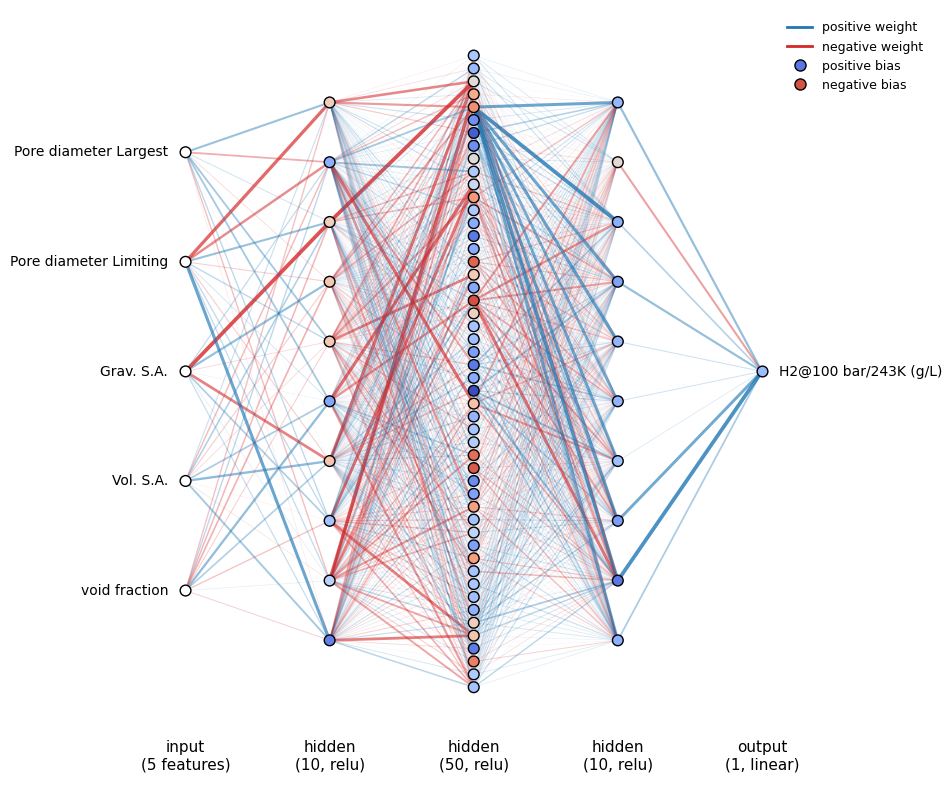

In [12]:
draw_network(model, node_labels=features, output_labels=output)
plt.show()